# Fill predictor

How well can the fill level be read from the spectrum, and from which
features? Run `01_setup_check.ipynb` on the same `DATA_DIR` first.

1. **Load** the runs and compute every candidate feature per capture
2. **Baseline, reproduced**: the original two-feature predictor, rescored
3. **Feature survey**: how each feature trends with fill, and how noisy it is
4. **Predictor comparison**: baseline vs the alternatives, under two tests
5. **`predict_water`**: point the chosen predictor at any capture

### How everything is scored

Per [ADR 0001](docs/adr/0001-predictor-evaluation-protocol.md), with terms from
`CONTEXT.md`:

- **One capture is one data point.** Its ~29 taps share its fill level and its
  moment in the rubber's loading history, so they are not independent samples.
  Resampling taps (the bootstrap) is only used for error bars on a feature.
- **Leave-one-level-out**: every fill level is predicted by a fit that never
  saw any run at that level.
- **Up→down test**: fit on the up-sweep only, predict the down-sweep. In the
  car fuel only goes down, and the rubber lags on the way down. A feature that
  passes leave-one-level-out but fails this one is tracking the rubber's
  loading history, not the fill.
- **Any feature choosing happens inside each fold**, so the quoted error
  includes the cost of choosing.

Fill is held in kg of water and shown in fl oz (1 cup = 8 fl oz).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr

import tapkit as tk

DATA_DIR = "data/2026-09-20_bucket-on-erasers"   # one setup folder
PRIMARY_BOARD = "A"    # beside the bucket
OTHER_BOARD = "B"      # farther away; the ratio A/B cancels tap strength
N_BOOT = 200           # tap resamples per capture, for feature error bars

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
UP, DOWN = "#2a78d6", "#eb6834"   # up-sweep, down-sweep, in every plot


def oz(kg):
    return float(tk.kg_to_oz(kg))

## 1. Load

A **capture** is one recording: a board-A file and a board-B file sharing a
timestamp. Each capture's sweep comes from when it was taken (everything up to
the first run at the top fill is the up-sweep), not from its trial number.

In [2]:
runs = tk.load_setup(DATA_DIR)
tk.add_spectra(runs)
table = tk.feature_table(runs, PRIMARY_BOARD, OTHER_BOARD)
NAMES = tk.FEATURE_NAMES

X = table[NAMES].values
y = table["water_kg"].values
sweep = table["sweep"].values
up = sweep == "up"

print(f"{len(table)} captures with both boards, {len(np.unique(y))} fill levels, "
      f"{up.sum()} up-sweep / {(~up).sum()} down-sweep\n")
print(table[["when", "lvl", "sweep", "n_taps"] + NAMES]
      .to_string(index=False, float_format=lambda v: f"{v:.3f}"))

14 captures with both boards, 8 fill levels, 9 up-sweep / 5 down-sweep

 when    lvl sweep  n_taps  table_peak_Hz  low/high  low/high_notch  dip_Hz  dip_depth_log  B_peak_Hz  B_low/high
23:27 0 cups    up      26         57.535     0.398           0.404  77.233         -0.589     74.148       0.223
23:32 0 cups    up      27         57.166     0.391           0.402  76.200         -0.863     74.148       0.243
23:37  50 oz    up      29         57.805     0.348           0.355  79.897         -0.727     71.289       0.218
23:40 100 oz    up      29         58.588     0.351           0.360  81.739         -0.762     71.134       0.217
23:42 150 oz    up      29         58.189     0.343           0.352  81.781         -0.877     70.585       0.207
23:44 200 oz    up      29         58.607     0.307           0.314  82.245         -1.060     74.148       0.188
23:46 250 oz    up      29         59.012     0.281           0.290  82.479         -1.191     74.148       0.178
23:48 300 oz    

## 2. Baseline, reproduced

The original predictor: a straight-line fit on the **table peak** (45–75 Hz)
and **low/high** (RMS 5–50 Hz over 50–150 Hz), both from board A. On 20 Sept it
scored ±27 oz leave-one-level-out with a worst miss of 50 oz. This cell checks
the refactored code gives the same number before anything is built on it, then
adds the up→down test it was never given.

In [3]:
baseline = tk.linear_model([NAMES.index("table_peak_Hz"), NAMES.index("low/high")])
p_lolo = tk.level_out(X, y, baseline)
p_ud = tk.up_down(X, y, sweep, baseline)

print(f"leave-one-level-out  ±{oz(tk.rmse(p_lolo, y)):.0f} oz RMS, worst miss {oz(tk.worst(p_lolo, y)):.0f} oz")
print(f"up->down test        ±{oz(tk.rmse(p_ud, y)):.0f} oz RMS, worst miss {oz(tk.worst(p_ud, y)):.0f} oz")
print(f"guessing the mean    ±{oz(np.std(y)):.0f} oz")

leave-one-level-out  ±27 oz RMS, worst miss 50 oz
up->down test        ±47 oz RMS, worst miss 90 oz
guessing the mean    ±113 oz


## 3. Feature survey

Every candidate feature, one at a time. The physical story for each:

| Feature | Board(s) | Story |
|---|---|---|
| `table_peak_Hz` | A | the table peak; rises as the rubber stiffens under load |
| `low/high` | A | RMS 5–50 Hz over 50–150 Hz; the bucket's weight makes the table near A sluggish at low frequency, a real mass effect |
| `low/high_notch` | A | the same with 27–31 Hz removed, because an outside 29 Hz line sits in the low band at every fill |
| `dip_Hz` | A/B | frequency of the ratio dip (65–100 Hz); the anti-resonance theory says to track from the frame |
| `dip_depth_log` | A/B | log10 of the A/B ratio at the dip |
| `B_peak_Hz` | B | the far board's tallest point in 45–75 Hz; expected to be a control |
| `B_low/high` | B | the far board's low/high; expected to be a control |

For each feature the table gives:

- **ρ**: Spearman rank correlation with fill. ±1 means it only ever moves one
  way as water goes in.
- **noise/trend**: the median tap-bootstrap standard deviation divided by the
  feature's full change across the fill levels. Small is good. Near 1 means one
  run's tap-to-tap noise is as big as the whole trend.
- **LOLO / up→down**: the error of a straight-line fit on this feature alone,
  under each test.

In [4]:
caps = tk.captures(runs)
boot_sd = np.array([
    tk.tap_bootstrap(caps[s][PRIMARY_BOARD], caps[s][OTHER_BOARD], n=N_BOOT, seed=i).std(axis=0)
    for i, s in enumerate(table["stamp"])
])   # (captures, features)

survey = []
for j, name in enumerate(NAMES):
    level_means = pd.Series(X[:, j]).groupby(y).mean()
    trend = level_means.max() - level_means.min()
    one = tk.linear_model([j])
    survey.append({
        "feature": name,
        "rho": spearmanr(X[:, j], y)[0],
        "noise/trend": np.median(boot_sd[:, j]) / trend,
        "LOLO_oz": oz(tk.rmse(tk.level_out(X, y, one), y)),
        "up->down_oz": oz(tk.rmse(tk.up_down(X, y, sweep, one), y)),
    })
survey = pd.DataFrame(survey)
print(survey.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

       feature   rho  noise/trend  LOLO_oz  up->down_oz
 table_peak_Hz  0.96         0.03    75.44        56.98
      low/high -0.97         0.06    34.52        33.04
low/high_notch -0.97         0.05    34.29        31.93
        dip_Hz  0.90         0.02    68.47        73.90
 dip_depth_log -0.91         0.04    62.85        46.25
     B_peak_Hz  0.16         0.02   161.25       214.32
    B_low/high -0.97         0.07    38.88        39.32


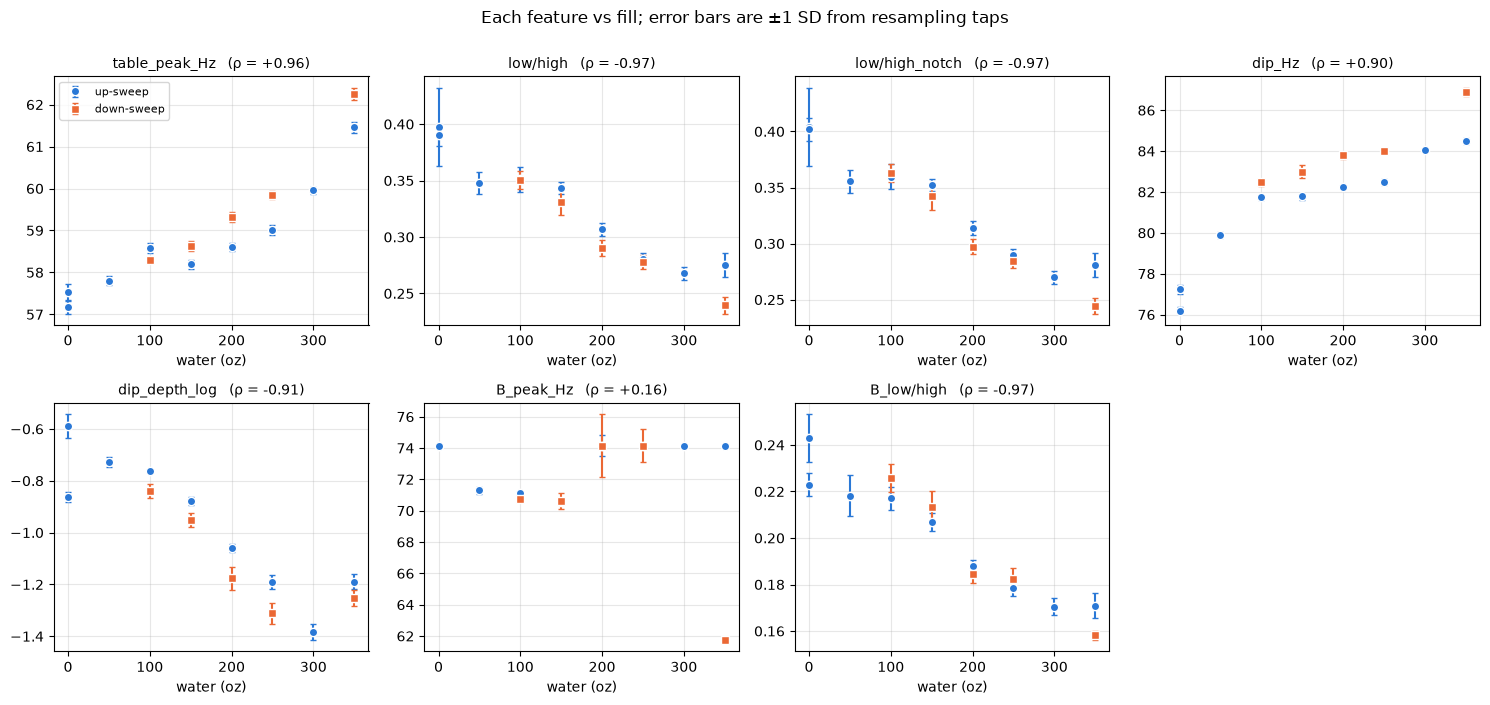

B_peak_Hz sits at the top edge of its band in 8 of 14 captures: board B has no peak in 45-75 Hz, so this feature is measuring the band edge.


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for j, (name, ax) in enumerate(zip(NAMES, axes.flat)):
    for mask, color, mk, label in ((up, UP, "o", "up-sweep"), (~up, DOWN, "s", "down-sweep")):
        ax.errorbar(tk.kg_to_oz(y[mask]), X[mask, j], yerr=boot_sd[mask, j],
                    fmt=mk, color=color, ms=6, mec="white", capsize=2, label=label)
    ax.set_title(f"{name}   (ρ = {survey.loc[j, 'rho']:+.2f})", fontsize=10)
    ax.set_xlabel("water (oz)")
axes.flat[-1].axis("off")
axes.flat[0].legend(fontsize=8)
fig.suptitle("Each feature vs fill; error bars are ±1 SD from resampling taps", y=1.0)
plt.tight_layout(); plt.show()

edge = [s for s, v in zip(table["when"], table["B_peak_Hz"])
        if v >= tk.TABLE_PEAK_BAND[1] - 1.0]
if edge:
    print(f"B_peak_Hz sits at the top edge of its band in {len(edge)} of {len(table)} captures: "
          "board B has no peak in 45-75 Hz, so this feature is measuring the band edge.")

### What the survey shows (20 Sept data)

- **The low/high family is the strongest and steadiest signal.** It moves one
  way with fill (ρ ≈ −0.97) and scores about the same under both tests, so it
  isn't bothered by the rubber's history. That fits its story: it's the one
  real mass effect.
- **The 29 Hz notch helps a little.** `low/high_notch` beats plain `low/high`
  slightly under both tests, so the notched version is the one carried forward.
- **The table peak and `dip_Hz` trend strongly but carry the rubber's
  history.** Down-sweep points sit above their up-sweep partners at the same
  fill: the hysteresis already seen in `01_setup_check`.
- **Board B is not a control.** `B_low/high` tracks fill almost as well as
  board A's. The whole table gets heavier, not just the spot next to the bucket.
- **`B_peak_Hz` is meaningless on this setup.** Board B has no peak in 45–75 Hz,
  so its "peak" is pinned to the band edge (see the note under the plots).

- **Tap noise is not the problem.** noise/trend is under 0.1 for every
  feature: resampling a run's taps barely moves any of them. The misses in
  section 4 come from differences *between* runs at the same fill (the rubber's
  history, the setup settling), not from measurement noise. More taps per run
  won't help. More runs, and a steadier mount, will.

These readings are specific to this setup. Rerun on a new `DATA_DIR` before
trusting any of them there.

## 4. Predictor comparison

Four candidates, all fixed **before** any of them was scored:

- **baseline**: `table_peak_Hz` + `low/high`, the original.
- **physics pick**: `dip_Hz` + `low/high_notch`. The ratio dip is the
  frame-side anti-resonance that theory says to track (its frequency depends on
  the tank's stiffness and mass, not the frame's), and low/high is the mass
  effect. This is chosen by reasoning, not by the scores.
- **auto search**: every straight-line fit on 1–3 of the seven features, with
  the subset chosen by leave-one-level-out **inside each fold**. If it agrees
  with the physics pick, good. If it picks something with no physical story,
  that's a warning, not a win.
- **PLS benchmark**: partial least squares on the whole log A/B ratio spectrum
  (5–150 Hz). There's no physical story behind it, so it isn't a gauge. It
  shows roughly how much fill information the spectrum holds in total.

**Choosing the winner:** the non-benchmark candidate with the lowest **worse of
its two scores**. The car only ever sees fuel going down, so a predictor that
aces leave-one-level-out but fails the up→down test would fail in use.

In [6]:
physics = tk.linear_model([NAMES.index("dip_Hz"), NAMES.index("low/high_notch")])
Z = tk.log_ratio_matrix(runs, table, PRIMARY_BOARD, OTHER_BOARD)

candidates = {
    "baseline":      (baseline, X),
    "physics pick":  (physics, X),
    "auto search":   (tk.subset_search(len(NAMES), max_k=3), X),
    "PLS benchmark": (tk.pls_model(max_components=3), Z),
}
BENCHMARKS = {"PLS benchmark"}

preds, scores = {}, []
for name, (model, feats) in candidates.items():
    lo = tk.level_out(feats, y, model)
    ud = tk.up_down(feats, y, sweep, model)
    preds[name] = (lo, ud)
    scores.append({"candidate": name,
                   "LOLO_oz": oz(tk.rmse(lo, y)), "LOLO_worst_oz": oz(tk.worst(lo, y)),
                   "up->down_oz": oz(tk.rmse(ud, y)), "up->down_worst_oz": oz(tk.worst(ud, y))})
scores = pd.DataFrame(scores)
scores["worse_of_two_oz"] = scores[["LOLO_oz", "up->down_oz"]].max(axis=1)
print(scores.to_string(index=False, float_format=lambda v: f"{v:.0f}"))
print(f"\nguessing the mean: ±{oz(np.std(y)):.0f} oz")

eligible = scores[~scores["candidate"].isin(BENCHMARKS)]
WINNER = eligible.loc[eligible["worse_of_two_oz"].idxmin(), "candidate"]
print(f"winner by the worse-of-two rule: {WINNER}")

# What the auto search chose in each fold. If this list is long, the search is
# fitting noise: the "best" subset depends on which level was held out.
search = candidates["auto search"][0]
print("\nauto search, subset chosen per leave-one-level-out fold:")
for lv in np.unique(y):
    keep = y != lv
    chosen = search(X[keep], y[keep]).chosen
    print(f"  without {oz(lv):3.0f} oz: " + " + ".join(NAMES[i] for i in chosen))

    candidate  LOLO_oz  LOLO_worst_oz  up->down_oz  up->down_worst_oz  worse_of_two_oz
     baseline       27             50           47                 90               47
 physics pick       37             85           39                 60               39
  auto search       53            129           47                 90               53
PLS benchmark       49            148           43                 63               49

guessing the mean: ±113 oz
winner by the worse-of-two rule: physics pick

auto search, subset chosen per leave-one-level-out fold:
  without   0 oz: dip_Hz + B_low/high
  without  50 oz: dip_Hz + B_low/high
  without 100 oz: table_peak_Hz + low/high
  without 150 oz: table_peak_Hz + low/high + B_peak_Hz
  without 200 oz: table_peak_Hz + dip_Hz + B_low/high
  without 250 oz: table_peak_Hz + dip_Hz + B_low/high
  without 300 oz: table_peak_Hz + low/high
  without 350 oz: dip_depth_log + B_peak_Hz + B_low/high


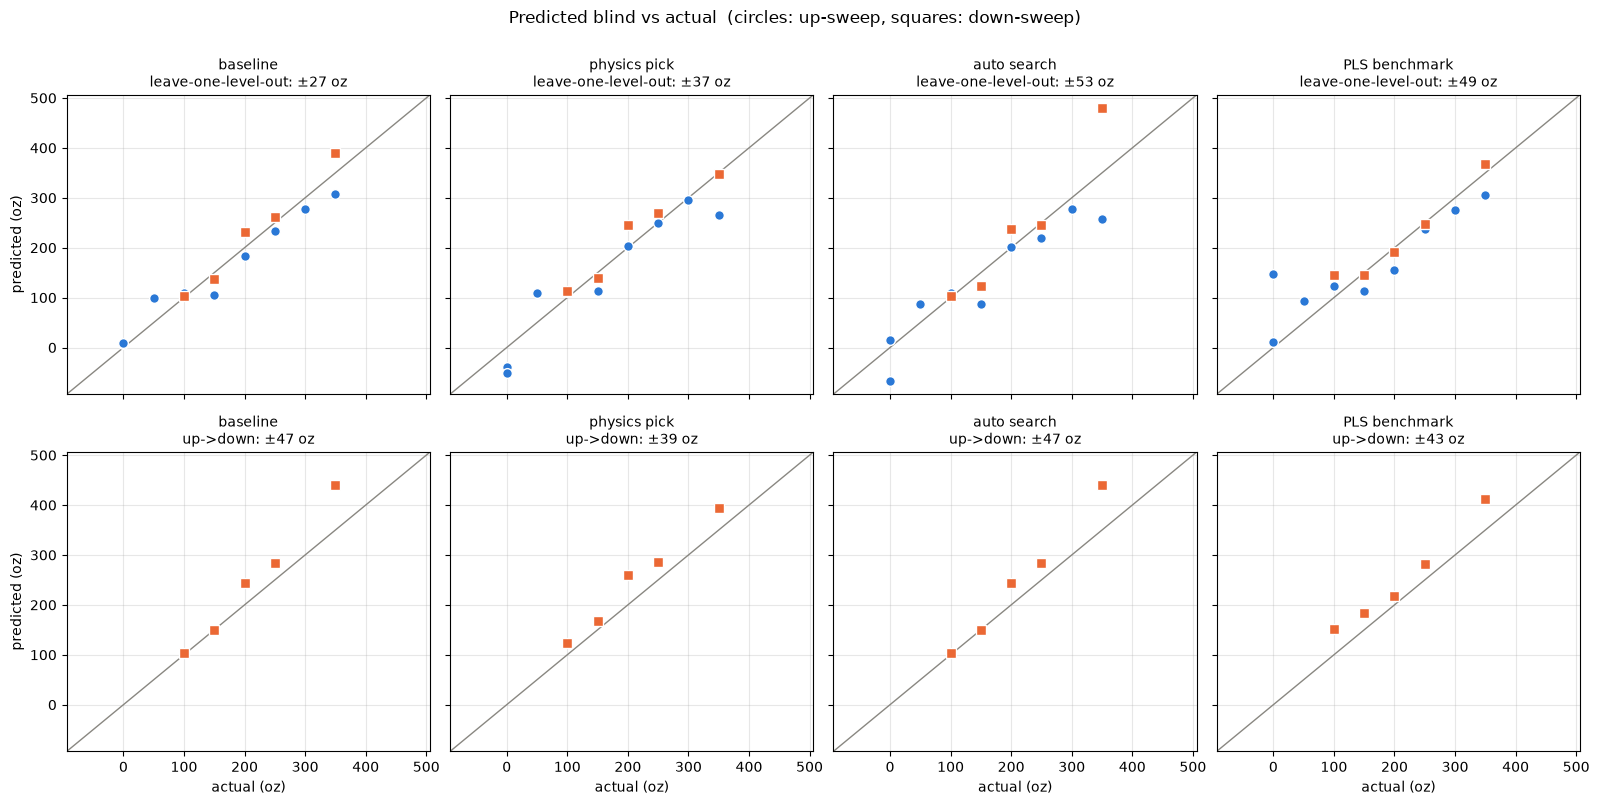

In [7]:
fig, axes = plt.subplots(2, len(candidates), figsize=(16, 8), sharex=True, sharey=True)
every = np.concatenate([tk.kg_to_oz(y)] + [tk.kg_to_oz(p[np.isfinite(p)]) for pp in preds.values() for p in pp])
pad = 0.05 * (every.max() - every.min())
lim = np.array([every.min() - pad, every.max() + pad])
for col, name in enumerate(candidates):
    for row, (label, p) in enumerate(zip(("leave-one-level-out", "up->down"), preds[name])):
        ax = axes[row, col]
        ax.plot(lim, lim, color="#898781", lw=1)
        for mask, color, mk in ((up, UP, "o"), (~up, DOWN, "s")):
            ok = mask & np.isfinite(p)
            ax.plot(tk.kg_to_oz(y[ok]), tk.kg_to_oz(p[ok]), mk, color=color, ms=7, mec="white")
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_title(f"{name}\n{label}: ±{oz(tk.rmse(p, y)):.0f} oz", fontsize=10)
        if row == 1: ax.set_xlabel("actual (oz)")
        if col == 0: ax.set_ylabel("predicted (oz)")
fig.suptitle("Predicted blind vs actual  (circles: up-sweep, squares: down-sweep)", y=1.0)
plt.tight_layout(); plt.show()

### What the comparison shows (20 Sept data)

- **The baseline's ±27 oz is mostly the rubber's history.** It is the best
  leave-one-level-out score here, but on the up→down test it's about ±47 oz,
  with a worst miss near 90 oz. The table peak it relies on reads high on the
  way down. It is also slightly optimistic in itself: its two features were
  picked on 20 Sept after looking at this same data.
- **The physics pick is the steadiest.** It's worse on leave-one-level-out
  (about ±37 oz) but better on the up→down test (about ±39 oz, worst miss about
  60), so it wins under the worse-of-two rule. It isn't free of the
  hysteresis, though: every one of its down-sweep predictions reads high,
  because `dip_Hz` also sits higher on the way down. The low/high half is doing
  the steady work.
- **The auto search does worst.** With 14 captures the "best" subset changes
  with whichever level is held out (see the per-fold list), and the nested
  score shows what that instability costs. More data, not more search, is the fix.
- **PLS lands in the same range as the named features.** The whole spectrum
  doesn't hold much more fill information than low/high already captures.
- **A lead, not a result:** `low/high_notch` alone scored about ±34 / ±32 in the
  survey, the best single number here. But it was spotted *after* looking at
  the survey, so that score is optimistic. An honest nested one-feature search
  (`tk.subset_search(len(NAMES), max_k=1)`) scores about ±43 / ±39. Declare it
  as a candidate **before** scoring the next setup's data.

**Bottom line:** on this setup, nothing reads the fill level better than about
±35–40 oz in a way that survives the rubber's hysteresis. That's about a third
of the ±113 oz you'd get from guessing. The mass mode itself still hasn't been
seen, and next experiment #1 (board B on the bucket) is what settles whether it
exists.

## 5. `predict_water`

Uses the winner from section 4, or set `CHOSEN` yourself. Point it at a board-A
file. It finds the board-B file with the same timestamp, and if the capture is
one of the calibration runs, it's left out of the fit first. The ± it quotes is
the chosen predictor's **worse** of its two scores.

To test it blind, record a run **without** `--oz` or `--cups`. The loader
leaves it out of calibration, and you can point `predict_water` at it.

In [8]:
CHOSEN = WINNER          # or e.g. "baseline"
if CHOSEN in BENCHMARKS:
    raise ValueError("The PLS benchmark has no physical story; pick a named-feature predictor.")
chosen_model = candidates[CHOSEN][0]
chosen_err_kg = scores.set_index("candidate").loc[CHOSEN, "worse_of_two_oz"] * tk.KG_PER_UNIT["oz"]


def predict_water(path):
    """Estimate the water in the bucket from one capture (give the board-A file)."""
    path = Path(path)
    stamp = path.name.rsplit("_", 2)[-2] + "_" + path.name.rsplit("_", 1)[-1][:-4]
    partner = list(path.parent.glob(f"run_*_{OTHER_BOARD}_{stamp}.csv"))
    if not partner:
        print(f"{path.name}: no board-{OTHER_BOARD} file with stamp {stamp} next to it.")
        return None

    boards = {}
    for p in (path, partner[0]):
        df, meta = tk.load_run(p)
        r = {"df": df, "meta": meta, "fs": 1.0 / np.median(np.diff(df["t_s"].values))}
        r["x"] = df["mpu_az"].values
        r["taps"] = tk.find_taps(r["x"], r["fs"])
        r["f"], r["amp"], r["n_taps"] = tk.tap_spectrum(r["x"], r["fs"], r["taps"])
        boards[p] = r
    a, b = boards[path], boards[partner[0]]
    if min(a["n_taps"], b["n_taps"]) < 5:
        print(f"{path.name}: too few usable taps ({a['n_taps']}, {b['n_taps']}), need 5.")
        return None
    feats = tk.features_from_spectra(a["f"], a["amp"], b["f"], b["amp"])
    xn = np.array([[feats[n] for n in NAMES]])

    keep = (table["stamp"] != stamp).values
    predict = chosen_model(X[keep], y[keep])
    kg = float(predict(xn)[0])

    print(path.name, f"   [{CHOSEN}]")
    print(f"  {a['n_taps']} taps   " + "   ".join(f"{n} {feats[n]:.3f}" for n in NAMES))
    print(f"  estimated water:  {tk.oz_and_cups(kg)}  ± {oz(chosen_err_kg):.0f} oz   ({kg:.2f} kg)")

    logged = next((k for k in tk.KG_PER_UNIT if k in a["meta"]), None)
    if logged is not None:
        actual = float(a["meta"][logged]) * tk.KG_PER_UNIT[logged]
        print(f"  logged when recorded: {tk.oz_and_cups(actual)}   (off by {oz(kg - actual):+.0f} oz)")

    cols = getattr(predict, "chosen", None) or getattr(chosen_model, "cols", range(len(NAMES)))
    lo, hi = X[keep].min(axis=0), X[keep].max(axis=0)
    outside = [NAMES[j] for j in cols if not lo[j] <= xn[0, j] <= hi[j]]
    if outside:
        print(f"  CAUTION: {', '.join(outside)} is outside the calibration range, "
              "so this is extrapolation. Trust it less.")
    return kg


# Point NEW_FILE at any board-A capture from this setup. Left empty, it demos
# on the capture nearest the middle of the calibrated range.
NEW_FILE = ""

if not NEW_FILE and len(table):
    middle = (y.min() + y.max()) / 2
    NEW_FILE = str(Path(DATA_DIR) / table.loc[np.argmin(np.abs(y - middle)), "name_a"])
if NEW_FILE:
    predict_water(NEW_FILE)

run_oz150_trial1_A_20260920_234209.csv    [physics pick]
  29 taps   table_peak_Hz 58.189   low/high 0.343   low/high_notch 0.352   dip_Hz 81.781   dip_depth_log -0.877   B_peak_Hz 70.585   B_low/high 0.207
  estimated water:  116 oz (14.5 cups)  ± 39 oz   (3.43 kg)
  logged when recorded: 150 oz (18.8 cups)   (off by -34 oz)
